<a href="https://colab.research.google.com/github/harshitapaila369-collab/harshu/blob/main/Copy_of_internship_1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

First 5 Rows of Dataset:
   longitude  latitude  housing_median_age  total_rooms  total_bedrooms  \
0    -114.31     34.19                15.0       5612.0          1283.0   
1    -114.47     34.40                19.0       7650.0          1901.0   
2    -114.56     33.69                17.0        720.0           174.0   
3    -114.57     33.64                14.0       1501.0           337.0   
4    -114.57     33.57                20.0       1454.0           326.0   

   population  households  median_income  median_house_value  
0      1015.0       472.0         1.4936             66900.0  
1      1129.0       463.0         1.8200             80100.0  
2       333.0       117.0         1.6509             85700.0  
3       515.0       226.0         3.1917             73400.0  
4       624.0       262.0         1.9250             65500.0  

Dataset Information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 17000 entries, 0 to 16999
Data columns (total 9 columns):
 #   Column     

/tmp/ipykernel_903/67071916.py:40: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  data[column].fillna(data[column].mean(), inplace=True)


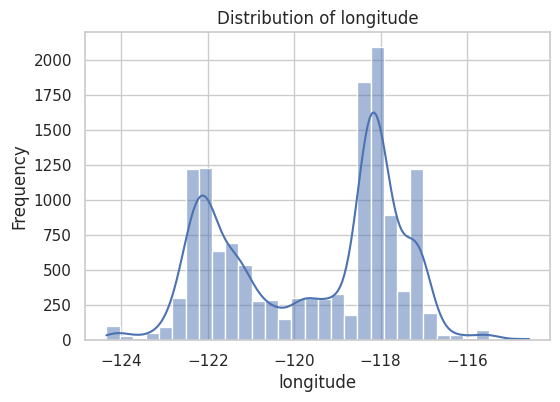

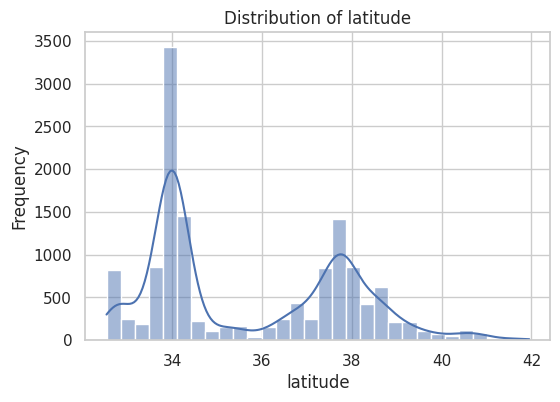

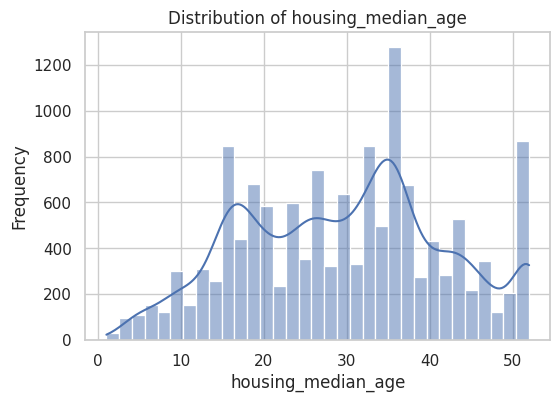

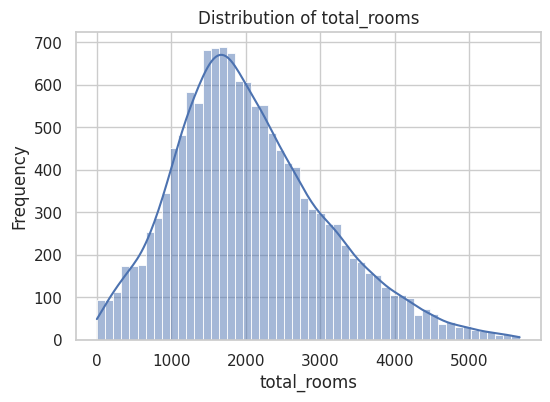

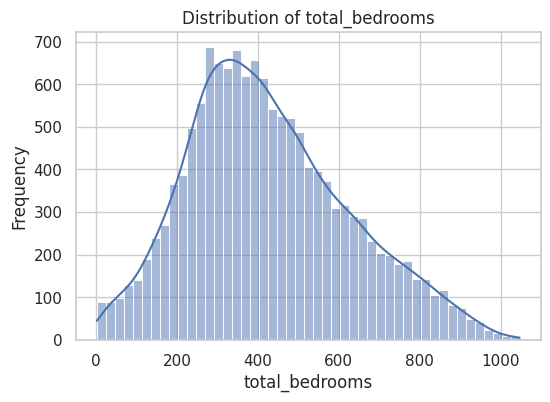

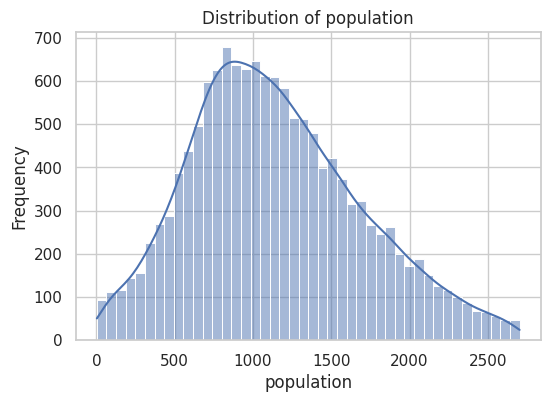

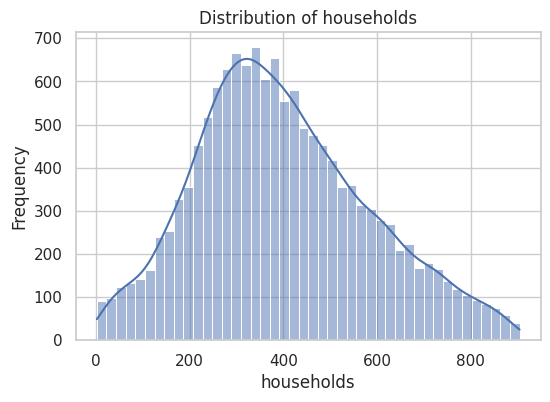

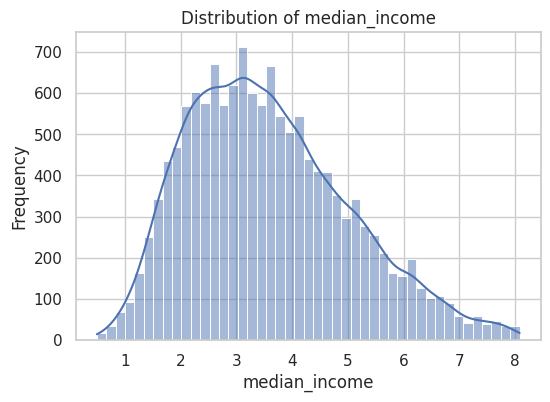

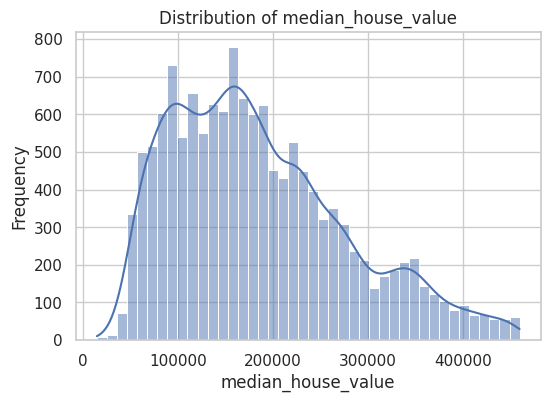

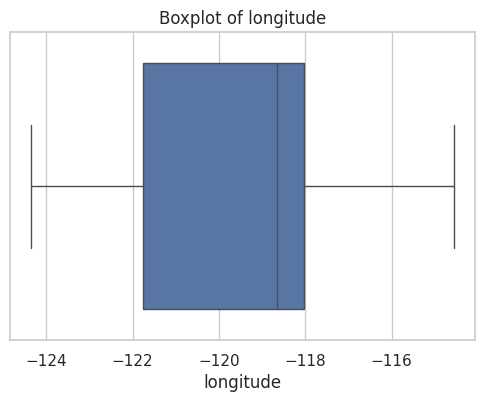

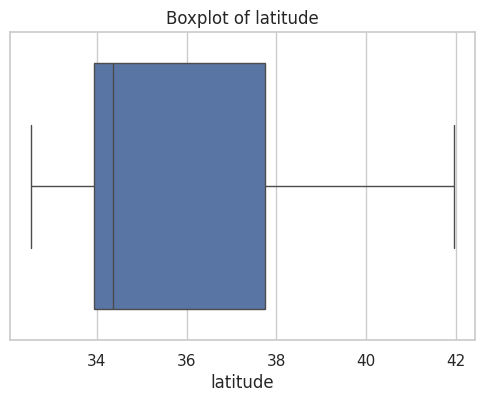

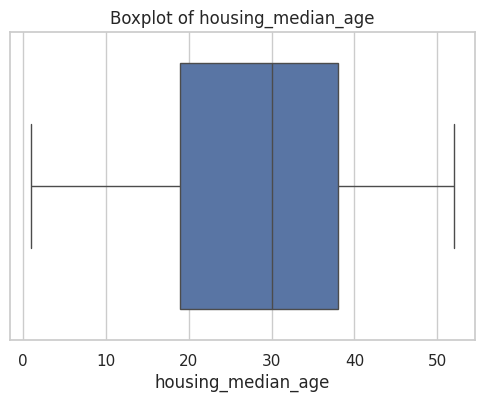

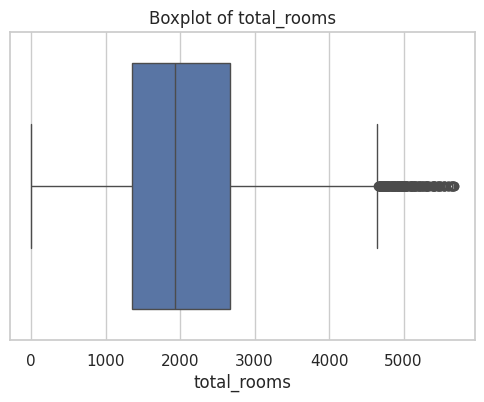

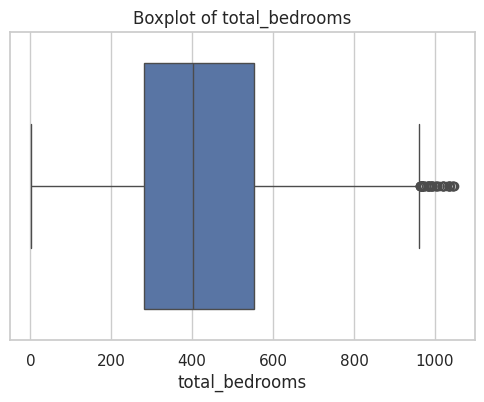

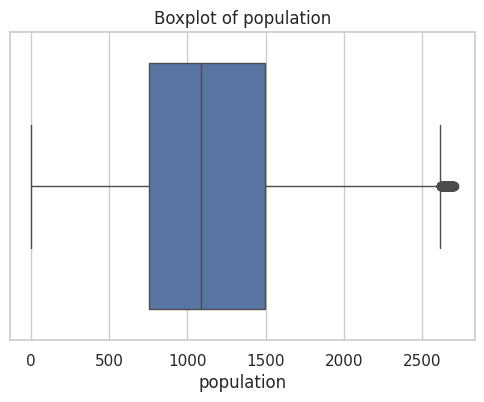

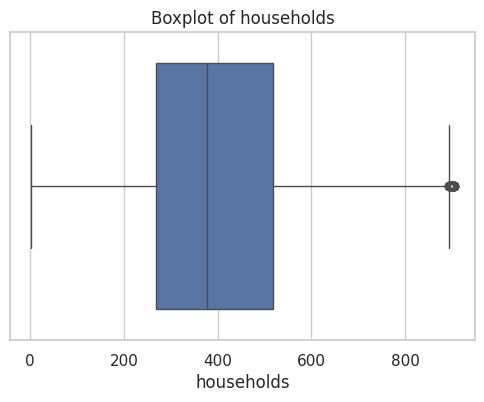

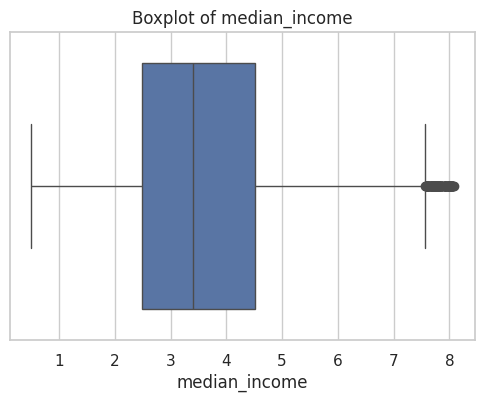

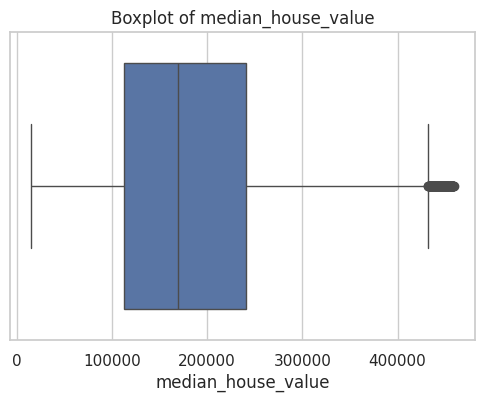

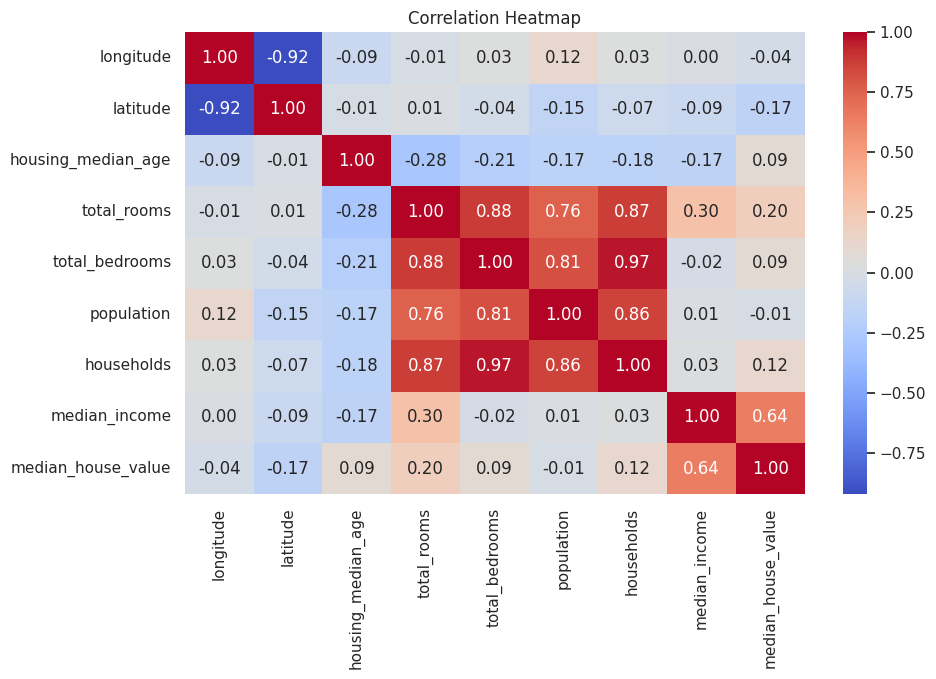


Cleaned Dataset Saved Successfully!

Data Cleaning & Visualization Completed Successfully!


In [1]:
# ============================================
# Data Cleaning & Visualization Project
# ============================================

# Import Required Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# --------------------------------------------
# Step 1: Load Dataset
# --------------------------------------------

# Replace 'dataset.csv' with your dataset file
data = pd.read_csv("/content/sample_data/california_housing_train.csv")

# Display first 5 rows
print("First 5 Rows of Dataset:")
print(data.head())

# --------------------------------------------
# Step 2: Check Dataset Information
# --------------------------------------------

print("\nDataset Information:")
print(data.info())

print("\nMissing Values:")
print(data.isnull().sum())

# --------------------------------------------
# Step 3: Handle Missing Values
# --------------------------------------------

# Fill numeric missing values with mean
numeric_columns = data.select_dtypes(include=np.number).columns

for column in numeric_columns:
    data[column].fillna(data[column].mean(), inplace=True)

# Fill categorical missing values with mode
categorical_columns = data.select_dtypes(include='object').columns

for column in categorical_columns:
    data[column].fillna(data[column].mode()[0], inplace=True)

print("\nMissing Values After Cleaning:")
print(data.isnull().sum())

# --------------------------------------------
# Step 4: Remove Duplicate Rows
# --------------------------------------------

print("\nNumber of Duplicate Rows:", data.duplicated().sum())

data.drop_duplicates(inplace=True)

print("Duplicates Removed Successfully!")

# --------------------------------------------
# Step 5: Handle Outliers
# --------------------------------------------

# Using IQR Method
for column in numeric_columns:

    Q1 = data[column].quantile(0.25)
    Q3 = data[column].quantile(0.75)
    IQR = Q3 - Q1

    lower_limit = Q1 - 1.5 * IQR
    upper_limit = Q3 + 1.5 * IQR

    data = data[
        (data[column] >= lower_limit) &
        (data[column] <= upper_limit)
    ]

print("\nOutliers Removed Successfully!")

# --------------------------------------------
# Step 6: Data Summary
# --------------------------------------------

print("\nStatistical Summary:")
print(data.describe())

# --------------------------------------------
# Step 7: Data Visualization
# --------------------------------------------

sns.set(style="whitegrid")

# 1. Histogram for Numeric Columns
for column in numeric_columns:
    plt.figure(figsize=(6,4))
    sns.histplot(data[column], kde=True)
    plt.title(f"Distribution of {column}")
    plt.xlabel(column)
    plt.ylabel("Frequency")
    plt.show()

# --------------------------------------------
# 2. Boxplot for Outlier Detection
# --------------------------------------------

for column in numeric_columns:
    plt.figure(figsize=(6,4))
    sns.boxplot(x=data[column])
    plt.title(f"Boxplot of {column}")
    plt.show()

# --------------------------------------------
# 3. Correlation Heatmap
# --------------------------------------------

plt.figure(figsize=(10,6))
correlation = data[numeric_columns].corr()

sns.heatmap(correlation,
            annot=True,
            cmap="coolwarm",
            fmt=".2f")

plt.title("Correlation Heatmap")
plt.show()

# --------------------------------------------
# 4. Count Plot for Categorical Data
# --------------------------------------------

for column in categorical_columns:
    plt.figure(figsize=(8,5))
    sns.countplot(x=data[column])

    plt.title(f"Count Plot of {column}")
    plt.xticks(rotation=45)
    plt.show()

# --------------------------------------------
# Step 8: Save Cleaned Dataset
# --------------------------------------------

data.to_csv("cleaned_dataset.csv", index=False)

print("\nCleaned Dataset Saved Successfully!")

# --------------------------------------------
# Project Completed
# --------------------------------------------

print("\nData Cleaning & Visualization Completed Successfully!")